In [1]:
import numpy as np

from rlbench.action_modes.action_mode import MoveArmThenGripper
from rlbench.action_modes.arm_action_modes import JointVelocity
from rlbench.action_modes.gripper_action_modes import Discrete
from rlbench.environment import Environment
from rlbench.observation_config import ObservationConfig, CameraConfig
from rlbench.task_environment import TaskEnvironment


from rlbench.backend.observation import Observation
from rlbench.demo import Demo

from pyrep.const import RenderMode
from pyrep.objects import Object

import numpy as np
import torch
import torch.nn.functional as F

from policy import Policy, Agent, CamType

import matplotlib.pyplot as plt

from utils import set_seed

##Tasks  
from rlbench.tasks.reach_target_no_obs_central import ReachTargetNoObsCentral as Central
from rlbench.tasks.reach_target_no_obs_side_r import ReachTargetNoObsSideR as SideR
from rlbench.tasks.reach_target_no_obs_side_l import ReachTargetNoObsSideL as SideL

set_seed(42)


In [2]:

cam_type = CamType.WRIST

live_demos = True
DATASET = '' if live_demos else 'PATH/TO/YOUR/DATASET'

obs_config = ObservationConfig()
obs_config.set_all(True) ## important to get the data from the joints etc
cam_config = CameraConfig(rgb=True, depth=False, mask=False,
                              render_mode=RenderMode.OPENGL,
                    image_size=(64, 64))
nocam_config = CameraConfig(rgb=False, depth=False, mask=False,
                          render_mode=RenderMode.OPENGL)

obs_config.right_shoulder_camera = cam_config
obs_config.left_shoulder_camera = cam_config
obs_config.overhead_camera = nocam_config
obs_config.front_camera = nocam_config

## active camera: wrist camera
obs_config.wrist_camera = cam_config


action_mode = MoveArmThenGripper(
    arm_action_mode=JointVelocity(), gripper_action_mode=Discrete())

env = Environment(
    action_mode, DATASET, obs_config, False)
env.launch()





In [3]:
def get_task_name(task) -> str:
  if task == Central:
    return "Central"
  elif task == SideL:
    return "Side Left"
  elif task == SideR:
    return "Side Right"
  else:
    raise ValueError("[request_demos_and_train_for_task] Task not found!")

## 
def request_demos_and_train_for_task(current_task, agent: Agent, num_demos: int,  save_model = False) -> TaskEnvironment:
  print(f"The Current Task is: {current_task}")
  
  task_name = get_task_name(current_task) 
  
  ## load this task into env
  task_env = env.get_task(current_task) # removes all other loaded tasks
  ## num_demos defined in the 
  demos: list[Demo] = task_env.get_demos(num_demos, live_demos=live_demos)
  agent.ingest(demos)
  if save_model:
    model_name = f"task-{task_name}-{num_demos}-demo-{cam_type}"
    model_path = f"./models/{model_name}.pth"
    agent.save_model(model_path)
  
  return task_env

- For each task, the episode length (number of frames captuures) is ~50, therefore will give the system 80 steps, maybe give it 500  to see if it does any corrections later?

In [5]:

from pprint import pprint
repeats = 10
tasks = [Central, SideR, SideL]
demo_counts = [1, 2, 5, 10]
results = [{
  task: {
    demo_count: {"min_dist": None, "final_dist": None}
    for demo_count in demo_counts
    
  }
  for task in tasks
} for _ in range(repeats)]

for i in range(repeats):
  for task in tasks:
    for demo_count in demo_counts:
      print(f"Training for {demo_count} demos for task {task}")
      ## new agent trained each time
      agent = Agent(env.action_shape[0], cam_type)
      
      ## request demos and train
      task_env = request_demos_and_train_for_task(task, agent, demo_count, save_model=True)
      
      ## evaluate
      obs: Observation
      _, obs = task_env.reset()
      agent.policy.to("cpu") # move to cpu
      distances = []
      for _ in range(80):
        action = agent.act(obs).squeeze()
        obs, reward, done = task_env.step(action)

        gripper = Object.get_object("Panda_gripper")
        target = Object.get_object("target")
        distance = np.linalg.norm(gripper.get_position() - target.get_position())
        distances.append(distance)
        if done:
          break
      
      results[i][task][demo_count]["min_dist"] = min(distances)
      results[i][task][demo_count]["final_dist"] = distance ## or distances[-1]
      


Training for 1 demos for task <class 'rlbench.tasks.reach_target_no_obs_central.ReachTargetNoObsCentral'>
The Current Task is: <class 'rlbench.tasks.reach_target_no_obs_central.ReachTargetNoObsCentral'>
What is in the demos: <class 'list'> | <class 'rlbench.demo.Demo'>
Dataset Size: 52


100%|██████████| 200/200 [00:00<00:00, 253.41it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Central-1-demo-wrist.pth'
Training for 2 demos for task <class 'rlbench.tasks.reach_target_no_obs_central.ReachTargetNoObsCentral'>
The Current Task is: <class 'rlbench.tasks.reach_target_no_obs_central.ReachTargetNoObsCentral'>
What is in the demos: <class 'list'> | <class 'rlbench.demo.Demo'>
Dataset Size: 104


100%|██████████| 200/200 [00:01<00:00, 133.85it/s]


Done Training Policy on 2 Demos
Saved Model under './models/task-Central-2-demo-wrist.pth'
Training for 5 demos for task <class 'rlbench.tasks.reach_target_no_obs_central.ReachTargetNoObsCentral'>
The Current Task is: <class 'rlbench.tasks.reach_target_no_obs_central.ReachTargetNoObsCentral'>
What is in the demos: <class 'list'> | <class 'rlbench.demo.Demo'>
Dataset Size: 260


...

Done Training Policy on 2 Demos
Saved Model under './models/task-Side Left-2-demo-wrist.pth'
Training for 5 demos for task <class 'rlbench.tasks.reach_target_no_obs_side_l.ReachTargetNoObsSideL'>
The Current Task is: <class 'rlbench.tasks.reach_target_no_obs_side_l.ReachTargetNoObsSideL'>
What is in the demos: <class 'list'> | <class 'rlbench.demo.Demo'>
Dataset Size: 270


100%|██████████| 200/200 [00:03<00:00, 54.67it/s]


Done Training Policy on 5 Demos
Saved Model under './models/task-Side Left-5-demo-wrist.pth'
Training for 10 demos for task <class 'rlbench.tasks.reach_target_no_obs_side_l.ReachTargetNoObsSideL'>
The Current Task is: <class 'rlbench.tasks.reach_target_no_obs_side_l.ReachTargetNoObsSideL'>
What is in the demos: <class 'list'> | <class 'rlbench.demo.Demo'>
Dataset Size: 540


100%|██████████| 200/200 [00:07<00:00, 28.42it/s]


Done Training Policy on 10 Demos
Saved Model under './models/task-Side Left-10-demo-wrist.pth'


In [ ]:
pprint(results, indent = 2)

In [ ]:
# tasks = []
# final_dists = []
# min_dists = []

# for task, values in results[0].items():
    
#     task_name = get_task_name(task)
      
#     tasks.append(task_name)
#     final_dists.append(values[1]['final_dist'])
#     min_dists.append(values[1]['min_dist'])

# # Plotting
# x = np.arange(len(tasks))  # Label positions

# plt.figure(figsize=(8, 5))
# plt.bar(x - 0.15, final_dists, width=0.3, label='Final Distance', color='blue', alpha=0.7)
# plt.bar(x + 0.15, min_dists, width=0.3, label='Min Distance', color='green', alpha=0.7)

# plt.xticks(x, tasks, rotation=20)
# plt.ylabel('Distance')
# plt.title('Final vs. Min Distance per Task')
# plt.legend()
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.show()

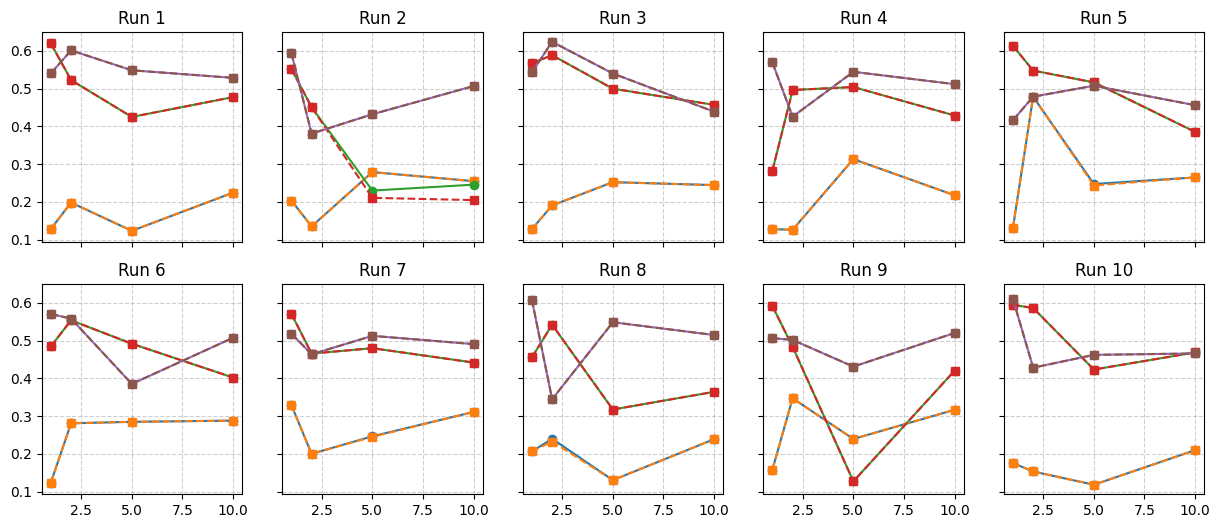

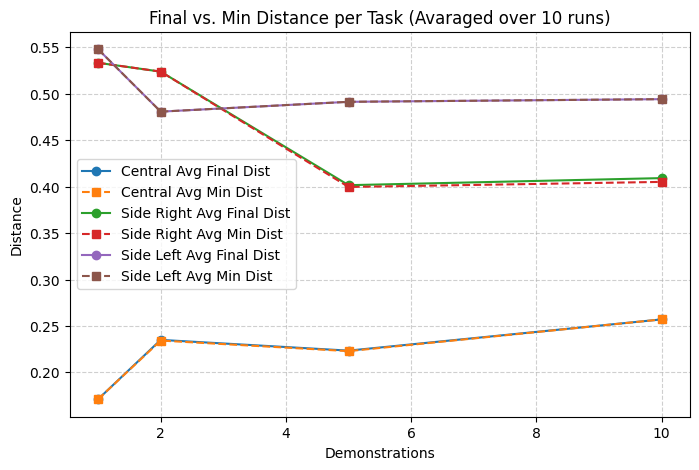

In [7]:
# Extracting tasks and distances
tasks = list(results[0].keys())

final_dists = {task: [results[0][task][demo]['final_dist'] for demo in demo_counts] for task in tasks}
min_dists = {task: [results[0][task][demo]['min_dist'] for demo in demo_counts] for task in tasks}

# Initialize figure
fig, axes = plt.subplots(2, (repeats + 1) // 2, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten()

# Collect data for averaging
final_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}
min_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}

# Plot individual runs
for run_idx in range(repeats):
  for task in tasks:
    task_name = get_task_name(task)
    final_dists = [results[run_idx][task][deom]['final_dist'] for deom in demo_counts]
    min_dists = [results[run_idx][task][deom]['min_dist'] for deom in demo_counts]
    
    final_dists_avg[task] += np.array(final_dists)
    min_dists_avg[task] += np.array(min_dists)
    
    axes[run_idx].plot(demo_counts, final_dists, marker='o', linestyle='-', label=f'{task_name} Final Dist')
    axes[run_idx].plot(demo_counts, min_dists, marker='s', linestyle='--', label=f'{task_name} Min Dist')
  
  axes[run_idx].set_title(f'Run {run_idx+1}')
  axes[run_idx].grid(True, linestyle='--', alpha=0.6)
    

# Average the distances
total_runs = 10
for task in tasks:
  final_dists_avg[task] /= total_runs
  min_dists_avg[task] /= total_runs

# Create an averaged graph
plt.figure(figsize=(8, 5))
for task in tasks:
  task_name = get_task_name(task)
  plt.plot(demo_counts, final_dists_avg[task], marker='o', linestyle='-', label=f'{task_name} Avg Final Dist')
  plt.plot(demo_counts, min_dists_avg[task], marker='s', linestyle='--', label=f'{task_name} Avg Min Dist')
    
    
plt.xlabel('Demonstrations')
plt.ylabel('Distance')
plt.title(f'Final vs. Min Distance per Task (Avaraged over {repeats} runs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
env.shutdown()

[CoppeliaSim:loadinfo]   done.
